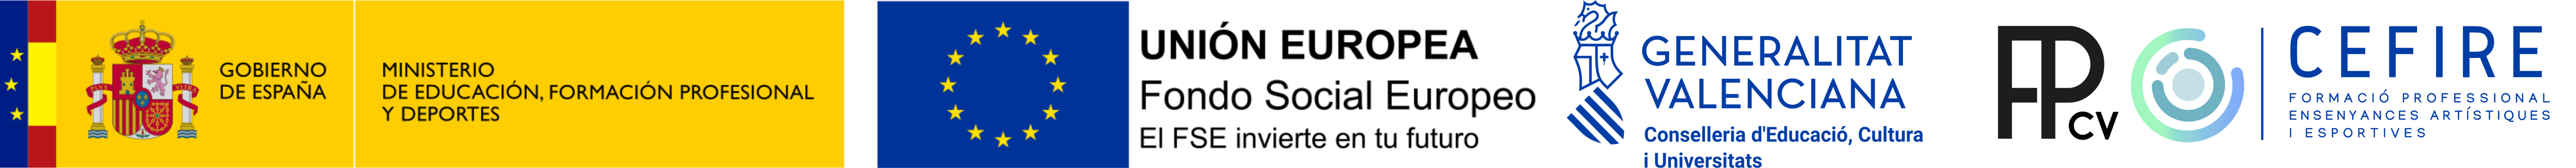

Vamos  crear una Web App que permita en base al tamaño del motor, los cilindros y el consumo indicar cual será el **consumo estimado de CO2**:

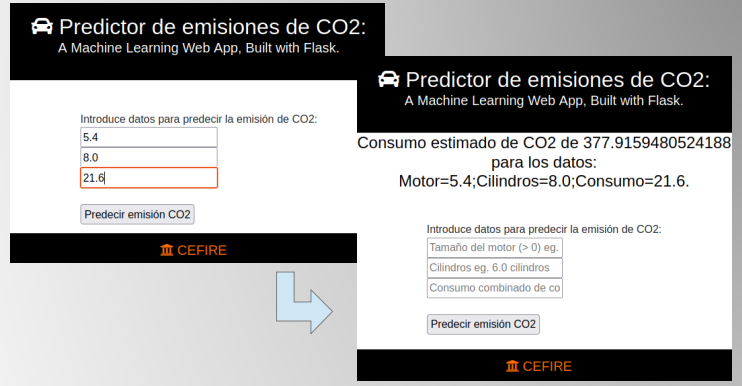

#### Para conseguirlo en este notebook nos centraremos en  crear un modelo que la webapp pueda utilizar realizando los siguientes pasos:
####     1.- Preparar el Dataset
####     2-  Crear los datos de entrenamiento y test
####     3-  Entrenar (train)
####     4-  Predecir con los datos de test
####     5-  Evaluar el modelo: Métricas
####     6-  Predecir simulando una entrada vía web  <-- Guiado
####     7.- Pipelines: Procesar datos de entrada  <-- Guiado
####     8.- Pickle: Persistir modelo  <-- Guiado


El foco de esta práctica no es el modelo, sino la **arquitectura** que implementaremos para crear una **webapp con Flask** de manera que podamos interactuar con el modelo haciendole preguntas a través de un navegador.


Para nuestra Webapp vamos a utilizar un modelo sencillo ya conocido, un **modelo de regresión múltiple** que nos permitia en base al tamaño del motor (Enginesize), el número de cilindros (Cylinders) y el consumo de carburante (FuelConsumption_Comb) predecir el CO2 que emitiamos (CO2Emissions):


**CO2EMISSIONS ≈ β₀ + β₁*ENGINESIZE + β₂*CYLINDERS + β₃*FUELCONSUMPTION_COMB**

### 1.- Preparar el Dataset

 Prepara el Dataset como lo hemos hecho en la práctica guiada:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   str    
 2   MODEL                     1067 non-null   str    
 3   VEHICLECLASS              1067 non-null   str    
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   str    
 7   FUELTYPE                  1067 non-null   str    
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 108.5 KB


In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


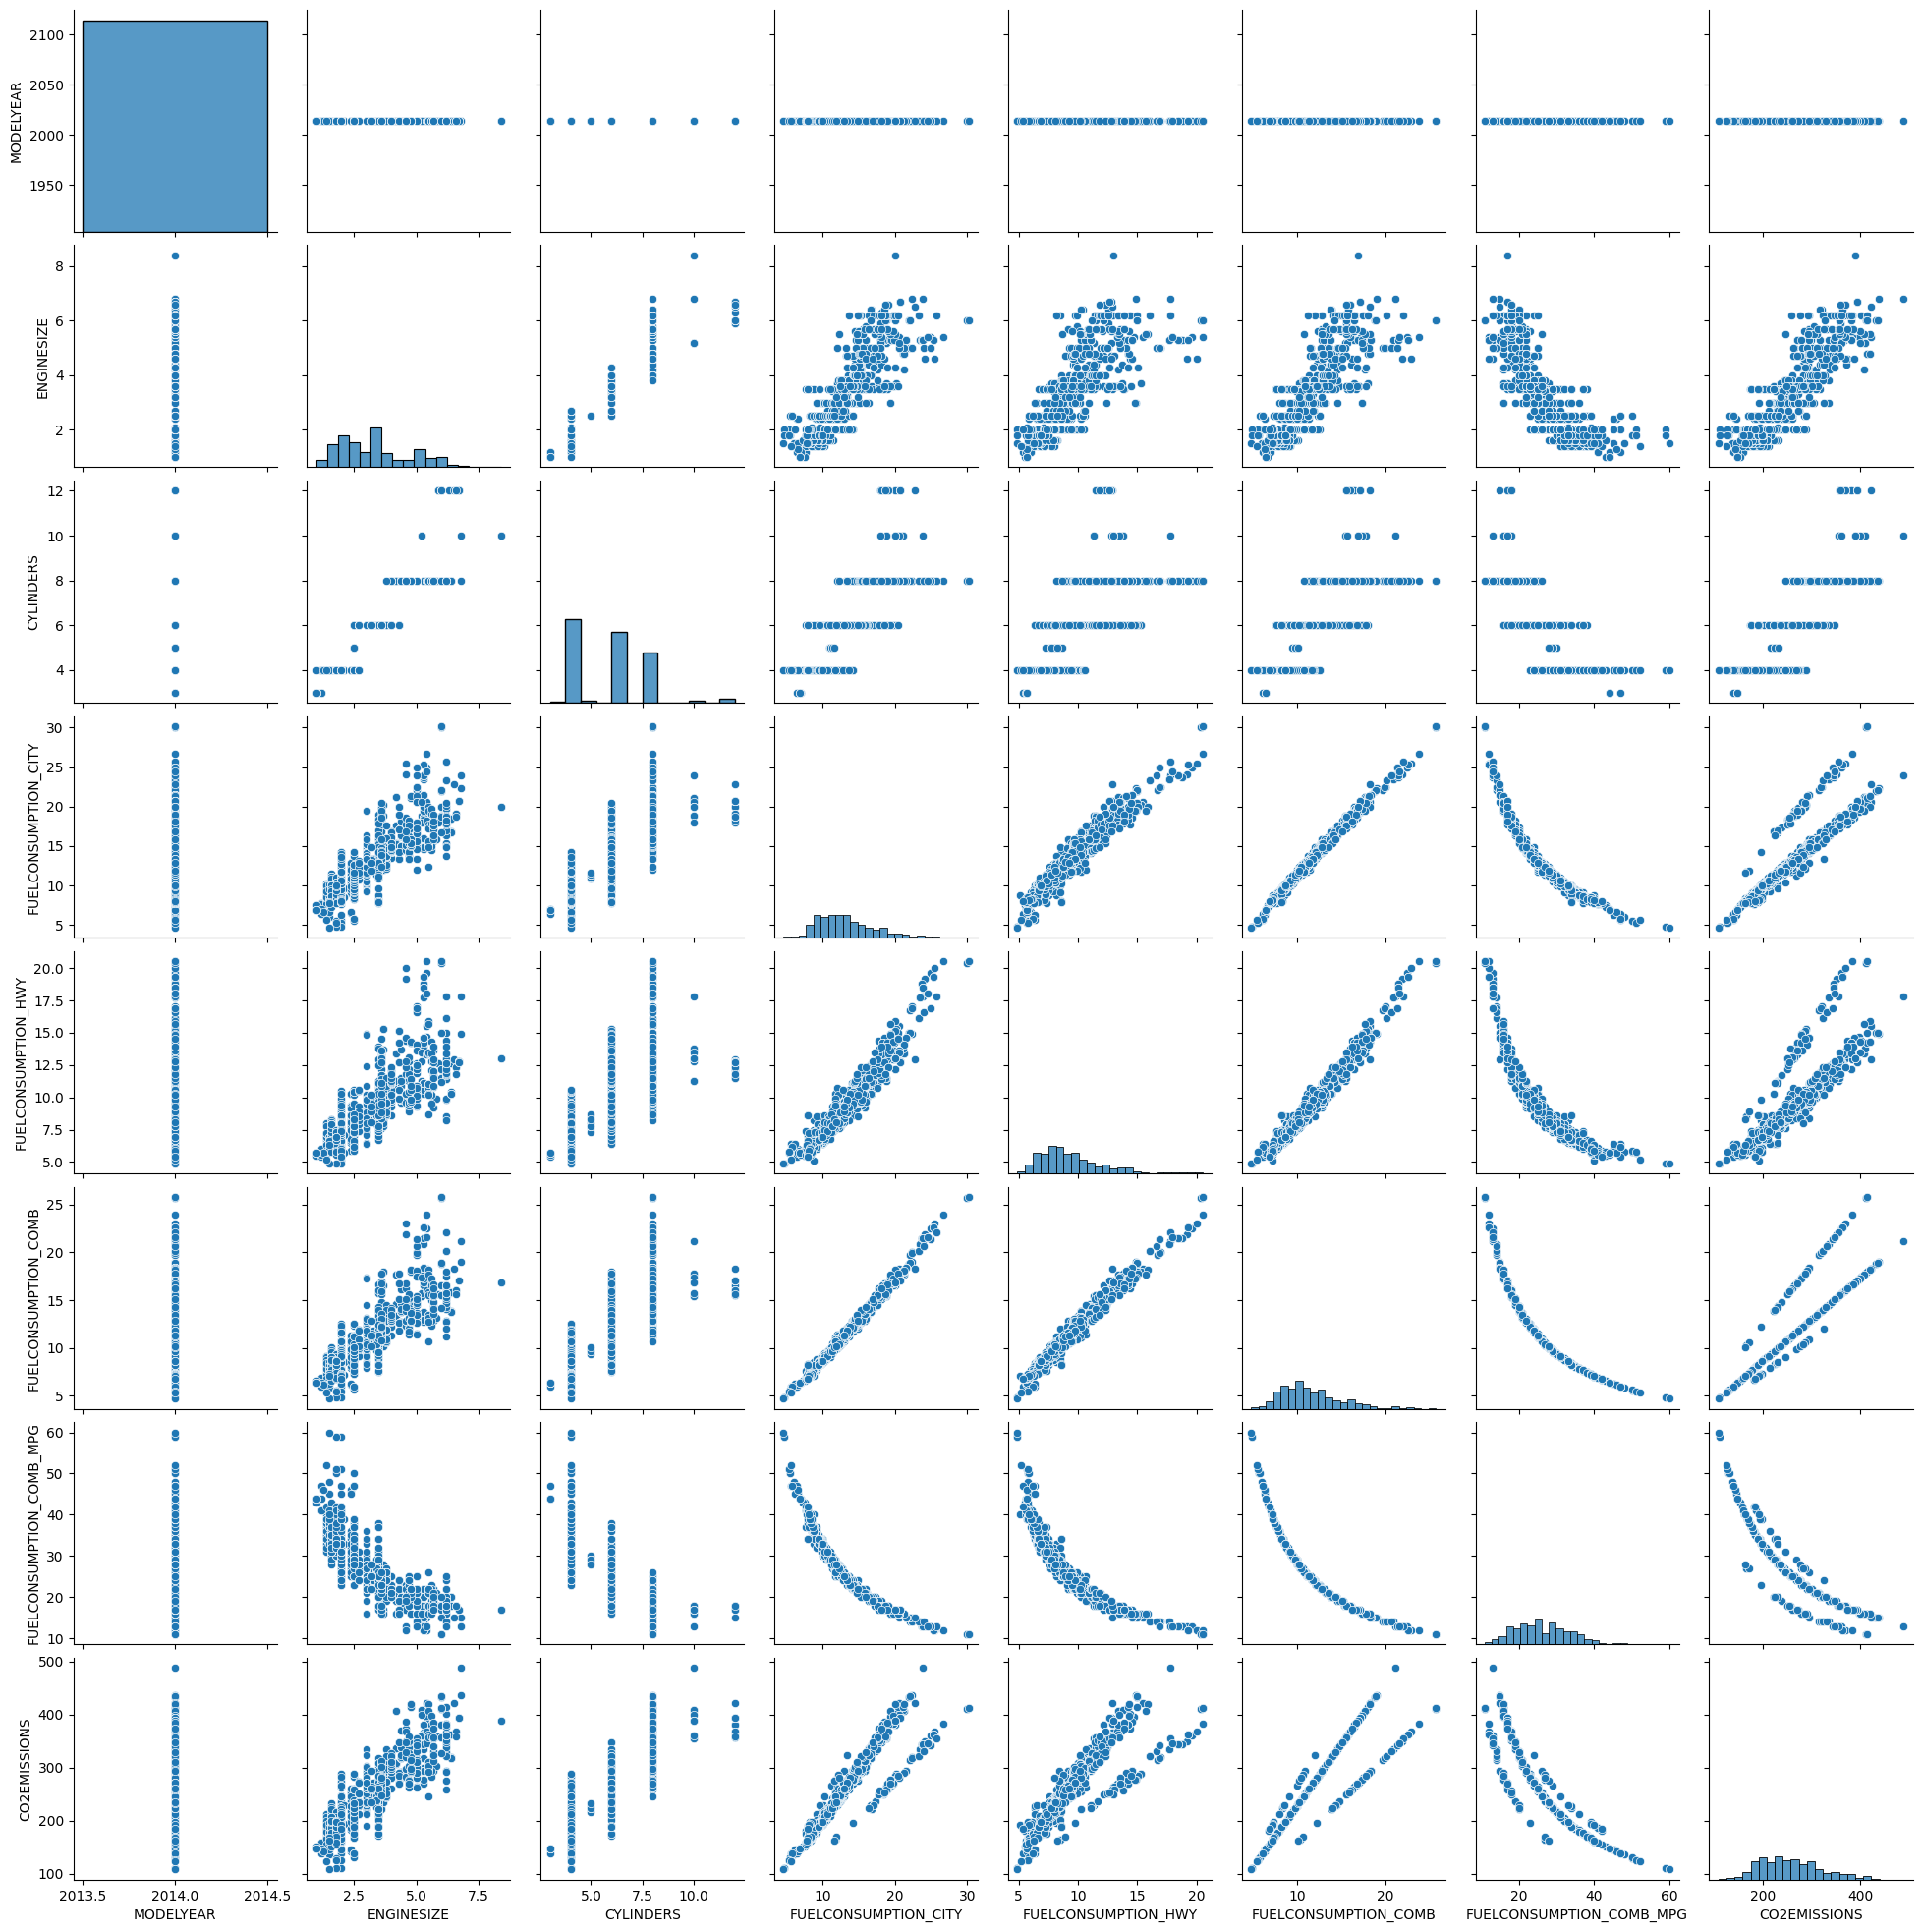

In [5]:
# Seleccionar solo las columnas numéricas
cdf = df[['MODELYEAR', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY',
          'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
          'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']]
# Crear la matriz de gráficos de dispersión
sns.pairplot(cdf)

# Mostrar los gráficos
plt.show()

In [6]:
# Seleccionar columnas de interés

# El propio objetivo de la actividad ya nos dice que el cálculo de las emisiones de C02 debe ser función de los 3 parámetros que la app va a admitir:
# - Engine Size
# - Cylinders
# - Fuel Consumption Comb

# Por lo tanto, seleccionamos estas columnas y la columna objetivo (CO2 Emissions) para el análisis.
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]

### 2- Crear los datos de entrenamiento y test
La división entrenamiento/test implicaba dividir el conjunto de datos en conjuntos que son mutuamente excluyentes. Después de lo cual, se entrenaba con el conjunto de entrenamiento y se valida con el conjunto de test.
Esto proporcionaba una evaluación más exacta de la precisión fuera de la muestra, ya que el conjunto de datos de la prueba no formaba parte del conjunto de datos que se utilizaba para entrenar el modelo. Es más realista para los problemas del mundo real.

Prepara los datos de entrenamiento y test:

In [7]:
from sklearn.model_selection import train_test_split

# --- División en Entrenamiento y Prueba ---
# Para la mayoría de los ejemplos, usaremos múltiples características
X_multi = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']] #Características o variables independientes
y = cdf['CO2EMISSIONS'] #Target o variable objetivo/dependiente

# Como norma general el 80% es para entrenamiento (X_train_multi,y_train) y el 20% para test(X_test_multi,y_test)
X_train_multi, X_test_multi, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Para regresión lineal simple y polinómica (con una variable para visualizar)
# Por cambiar vamos a probarla todas las variables de una en una, para ver cuál se ajusta mejor a la variable objetivo (CO2 Emissions)

X_simple_engine = cdf[['ENGINESIZE']]
X_simple_cylinders = cdf[['CYLINDERS']]
X_simple_fuelconsumption = cdf[['FUELCONSUMPTION_COMB']]

X_train_simple_engine, X_test_simple_engine, y_train_simple_engine, y_test_simple_engine = train_test_split(X_simple_engine, y, test_size=0.2, random_state=42)
X_train_simple_cylinders, X_test_simple_cylinders, y_train_simple_cylinders, y_test_simple_cylinders = train_test_split(X_simple_cylinders, y, test_size=0.2, random_state=42)
X_train_simple_fuelconsumption, X_test_simple_fuelconsumption, y_train_simple_fuelconsumption, y_test_simple_fuelconsumption = train_test_split(X_simple_fuelconsumption, y, test_size=0.2, random_state=42)


print(f"Tamaño del conjunto de entrenamiento (múltiple): {X_train_multi.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (múltiple): {X_test_multi.shape[0]} muestras")
print(f"Tamaño del conjunto de entrenamiento (simple - todos deberían ser iguales en tamaño): {X_train_simple_engine.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (simple - todos deberían ser iguales en tamaño): {X_test_simple_engine.shape[0]} muestras")


Tamaño del conjunto de entrenamiento (múltiple): 853 muestras
Tamaño del conjunto de prueba (múltiple): 214 muestras
Tamaño del conjunto de entrenamiento (simple - todos deberían ser iguales en tamaño): 853 muestras
Tamaño del conjunto de prueba (simple - todos deberían ser iguales en tamaño): 214 muestras


### 3- Entrenar (train)
Realizamos el entrenamiento con una regresión lineal múltiple:

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Regresión Lineal Múltiple
# 1. Crear instancia del modelo
# 1. Crear instancia del modelo
lin_reg_simple_engine = LinearRegression()
lin_reg_simple_cylinders = LinearRegression()
lin_reg_simple_fuelconsumption = LinearRegression()

lin_reg_multi = LinearRegression()

# 2. Entrenar modelos simples
lin_reg_simple_engine.fit(X_train_simple_engine, y_train)
lin_reg_simple_cylinders.fit(X_train_simple_cylinders, y_train)
lin_reg_simple_fuelconsumption.fit(X_train_simple_fuelconsumption, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


--- Coeficientes del Modelo Lineal Simple: ENGINESIZE ---
Coeficiente (Pendiente β₁ - ENGINESIZE): 38.99
  Interpretación β₁: Por cada unidad de aumento en ENGINESIZE, las CO2EMISSIONS aumentan en promedio 38.99 g/km.
Intersección (β₀): 126.29
  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando ENGINESIZE es 0 es 126.29 g/km (puede no tener sentido físico directo).
  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ 126.29 + 38.99 * ENGINESIZE

--- Evaluación del Modelo (sobre datos de prueba) ---
R² (Coeficiente de Determinación): 0.7616
  Interpretación R²: Aproximadamente el 76.16% de la varianza en las emisiones de CO2 (en el test set) es explicada por el tamaño del motor según este modelo lineal.

MSE (Mean Squared Error): 985.94
  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.

RMSE (Root Mean Squared Error): 31.40
  Interpretación RMSE: En promedio, las pre

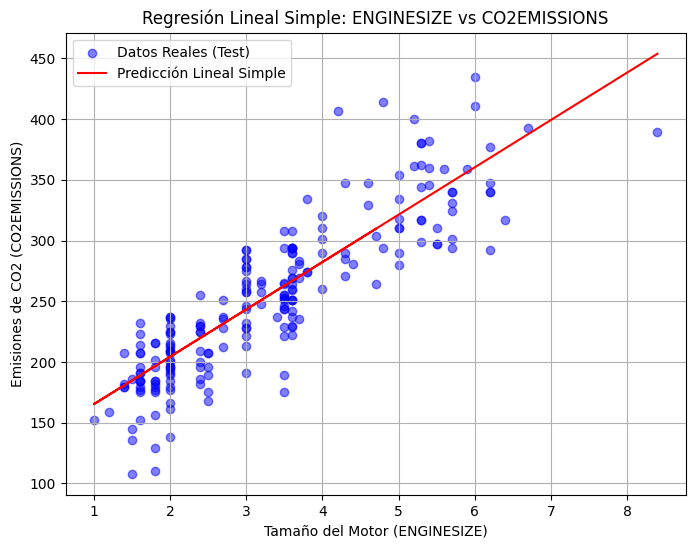

In [9]:
# 3. Coeficientes encontrados e interpretación para ENGINESIZE
beta_1_engine = lin_reg_simple_engine.coef_[0]
beta_0_engine = lin_reg_simple_engine.intercept_
print(f"--- Coeficientes del Modelo Lineal Simple: ENGINESIZE ---")
print(f"Coeficiente (Pendiente β₁ - ENGINESIZE): {beta_1_engine:.2f}")
print(f"  Interpretación β₁: Por cada unidad de aumento en ENGINESIZE, las CO2EMISSIONS aumentan en promedio {beta_1_engine:.2f} g/km.")
print(f"Intersección (β₀): {beta_0_engine:.2f}")
print(f"  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando ENGINESIZE es 0 es {beta_0_engine:.2f} g/km (puede no tener sentido físico directo).")
print(f"  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ {beta_0_engine:.2f} + {beta_1_engine:.2f} * ENGINESIZE")


# 4. Predecir en el conjunto de prueba
y_pred_simple_engine = lin_reg_simple_engine.predict(X_test_simple_engine)

# 5. Evaluar e interpretar métricas: R1, MSE, RMSE
print(f"\n--- Evaluación del Modelo (sobre datos de prueba) ---")

# R²
r2_simple = r2_score(y_test_simple_engine, y_pred_simple_engine)
print(f"R² (Coeficiente de Determinación): {r2_simple:.4f}")
print(f"  Interpretación R²: Aproximadamente el {r2_simple*100:.2f}% de la varianza en las emisiones de CO2 (en el test set) es explicada por el tamaño del motor según este modelo lineal.")

# MSE
mse_simple = mean_squared_error(y_test_simple_engine, y_pred_simple_engine)
print(f"\nMSE (Mean Squared Error): {mse_simple:.2f}")
print(f"  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.")

# RMSE
rmse_simple = np.sqrt(mse_simple)
print(f"\nRMSE (Root Mean Squared Error): {rmse_simple:.2f}")
print(f"  Interpretación RMSE: En promedio, las predicciones de emisiones de CO2 del modelo se desvían unos {rmse_simple:.2f} g/km de los valores reales. Es el error típico en las unidades originales.")


print(f"\n--- Evaluación (Simple) ---")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"R²: {r2_simple:.4f}")

# 6. Visualización (Opcional pero Recomendado)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple_engine, y_test_simple_engine, color='blue', alpha=0.5, label='Datos Reales (Test)')
# X_test_simple es un Dataframe y la función plot espera un array de 1 dimensión 
# por lo que extraemos la columna como una Serie con .iloc[:, 0]
plt.plot(X_test_simple_engine.iloc[:, 0], y_pred_simple_engine, color='red', label='Predicción Lineal Simple')
plt.title('Regresión Lineal Simple: ENGINESIZE vs CO2EMISSIONS')
plt.xlabel('Tamaño del Motor (ENGINESIZE)')
plt.ylabel('Emisiones de CO2 (CO2EMISSIONS)')
plt.legend()
plt.grid(True)
plt.show()

--- Coeficientes del Modelo Lineal Simple: CYLINDERS ---
Coeficiente (Pendiente β₁ - CYLINDERS): 29.48
  Interpretación β₁: Por cada cilindro adicional, las CO2EMISSIONS aumentan en promedio 29.48 g/km.
Intersección (β₀): 86.09
  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando CYLINDERS es 0 es 86.09 g/km (puede no tener sentido físico directo).
  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ 86.09 + 29.48 * CYLINDERS
--- Evaluación del Modelo (sobre datos de prueba) ---
R² (Coeficiente de Determinación): 0.7317
  Interpretación R²: Aproximadamente el 73.17% de la varianza en las emisiones de CO2 (en el test set) es explicada por el número de cilindros según este modelo lineal.
MSE (Mean Squared Error): 1109.35
  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.
RMSE (Root Mean Squared Error): 33.31
  Interpretación RMSE: En promedio, las predicciones de emisio

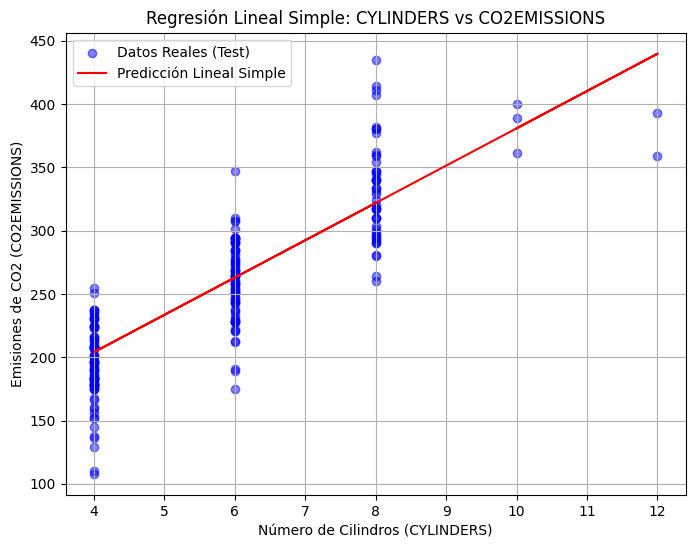

In [10]:
# 3. Coeficientes encontrados e interpretación para CYLINDERS
beta_1_cylinders = lin_reg_simple_cylinders.coef_[0]
beta_0_cylinders = lin_reg_simple_cylinders.intercept_
print(f"--- Coeficientes del Modelo Lineal Simple: CYLINDERS ---")
print(f"Coeficiente (Pendiente β₁ - CYLINDERS): {beta_1_cylinders:.2f}")
print(f"  Interpretación β₁: Por cada cilindro adicional, las CO2EMISSIONS aumentan en promedio {beta_1_cylinders:.2f} g/km.")
print(f"Intersección (β₀): {beta_0_cylinders:.2f}")
print(f"  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando CYLINDERS es 0 es {beta_0_cylinders:.2f} g/km (puede no tener sentido físico directo).")
print(f"  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ {beta_0_cylinders:.2f} + {beta_1_cylinders:.2f} * CYLINDERS")


# 4. Predecir en el conjunto de prueba
y_pred_simple_cylinders = lin_reg_simple_cylinders.predict(X_test_simple_cylinders)

# 5. Evaluar e interpretar métricas: R², MSE, RMSE
print(f"--- Evaluación del Modelo (sobre datos de prueba) ---")

# R²
r2_simple = r2_score(y_test_simple_cylinders, y_pred_simple_cylinders)
print(f"R² (Coeficiente de Determinación): {r2_simple:.4f}")
print(f"  Interpretación R²: Aproximadamente el {r2_simple*100:.2f}% de la varianza en las emisiones de CO2 (en el test set) es explicada por el número de cilindros según este modelo lineal.")

# MSE
mse_simple = mean_squared_error(y_test_simple_cylinders, y_pred_simple_cylinders)
print(f"MSE (Mean Squared Error): {mse_simple:.2f}")
print(f"  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.")

# RMSE
rmse_simple = np.sqrt(mse_simple)
print(f"RMSE (Root Mean Squared Error): {rmse_simple:.2f}")
print(f"  Interpretación RMSE: En promedio, las predicciones de emisiones de CO2 del modelo se desvían unos {rmse_simple:.2f} g/km de los valores reales. Es el error típico en las unidades originales.")


print(f"--- Evaluación (Simple) ---")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"R²: {r2_simple:.4f}")

# 6. Visualización
plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple_cylinders, y_test_simple_cylinders, color='blue', alpha=0.5, label='Datos Reales (Test)')
plt.plot(X_test_simple_cylinders.iloc[:, 0], y_pred_simple_cylinders, color='red', label='Predicción Lineal Simple')
plt.title('Regresión Lineal Simple: CYLINDERS vs CO2EMISSIONS')
plt.xlabel('Número de Cilindros (CYLINDERS)')
plt.ylabel('Emisiones de CO2 (CO2EMISSIONS)')
plt.legend()
plt.grid(True)
plt.show()

--- Coeficientes del Modelo Lineal Simple: FUELCONSUMPTION_COMB ---
Coeficiente (Pendiente β₁ - FUELCONSUMPTION_COMB): 16.18
  Interpretación β₁: Por cada unidad de aumento en FUELCONSUMPTION_COMB, las CO2EMISSIONS aumentan en promedio 16.18 g/km.
Intersección (β₀): 69.10
  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando FUELCONSUMPTION_COMB es 0 es 69.10 g/km (puede no tener sentido físico directo).
  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ 69.10 + 16.18 * FUELCONSUMPTION_COMB
--- Evaluación del Modelo (sobre datos de prueba) ---
R² (Coeficiente de Determinación): 0.8071
  Interpretación R²: Aproximadamente el 80.71% de la varianza en las emisiones de CO2 (en el test set) es explicada por el consumo combinado de combustible según este modelo lineal.
MSE (Mean Squared Error): 797.43
  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.
RMSE (Root Mean Squar

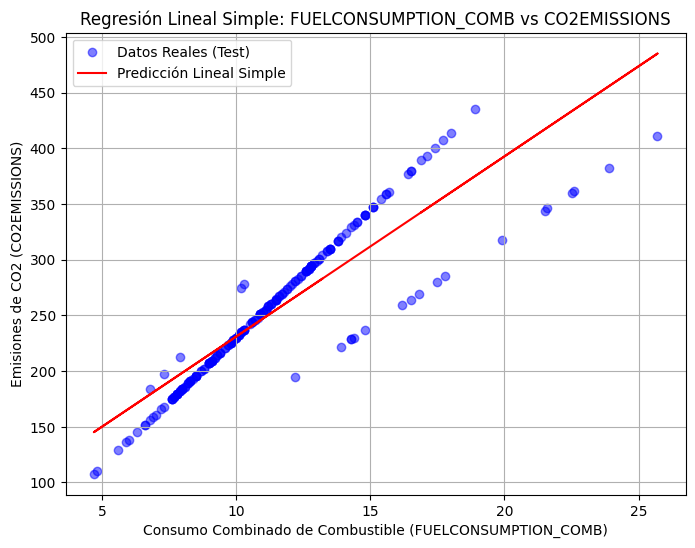

In [11]:
# 3. Coeficientes encontrados e interpretación para FUELCONSUMPTION_COMB
beta_1_fuelconsumption = lin_reg_simple_fuelconsumption.coef_[0]
beta_0_fuelconsumption = lin_reg_simple_fuelconsumption.intercept_
print(f"--- Coeficientes del Modelo Lineal Simple: FUELCONSUMPTION_COMB ---")
print(f"Coeficiente (Pendiente β₁ - FUELCONSUMPTION_COMB): {beta_1_fuelconsumption:.2f}")
print(f"  Interpretación β₁: Por cada unidad de aumento en FUELCONSUMPTION_COMB, las CO2EMISSIONS aumentan en promedio {beta_1_fuelconsumption:.2f} g/km.")
print(f"Intersección (β₀): {beta_0_fuelconsumption:.2f}")
print(f"  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando FUELCONSUMPTION_COMB es 0 es {beta_0_fuelconsumption:.2f} g/km (puede no tener sentido físico directo).")
print(f"  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ {beta_0_fuelconsumption:.2f} + {beta_1_fuelconsumption:.2f} * FUELCONSUMPTION_COMB")


# 4. Predecir en el conjunto de prueba
y_pred_simple_fuelconsumption = lin_reg_simple_fuelconsumption.predict(X_test_simple_fuelconsumption)

# 5. Evaluar e interpretar métricas: R², MSE, RMSE
print(f"--- Evaluación del Modelo (sobre datos de prueba) ---")

# R²
r2_simple = r2_score(y_test_simple_fuelconsumption, y_pred_simple_fuelconsumption)
print(f"R² (Coeficiente de Determinación): {r2_simple:.4f}")
print(f"  Interpretación R²: Aproximadamente el {r2_simple*100:.2f}% de la varianza en las emisiones de CO2 (en el test set) es explicada por el consumo combinado de combustible según este modelo lineal.")

# MSE
mse_simple = mean_squared_error(y_test_simple_fuelconsumption, y_pred_simple_fuelconsumption)
print(f"MSE (Mean Squared Error): {mse_simple:.2f}")
print(f"  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.")

# RMSE
rmse_simple = np.sqrt(mse_simple)
print(f"RMSE (Root Mean Squared Error): {rmse_simple:.2f}")
print(f"  Interpretación RMSE: En promedio, las predicciones de emisiones de CO2 del modelo se desvían unos {rmse_simple:.2f} g/km de los valores reales. Es el error típico en las unidades originales.")


print(f"--- Evaluación (Simple) ---")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"R²: {r2_simple:.4f}")

# 6. Visualización
plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple_fuelconsumption, y_test_simple_fuelconsumption, color='blue', alpha=0.5, label='Datos Reales (Test)')
plt.plot(X_test_simple_fuelconsumption.iloc[:, 0], y_pred_simple_fuelconsumption, color='red', label='Predicción Lineal Simple')
plt.title('Regresión Lineal Simple: FUELCONSUMPTION_COMB vs CO2EMISSIONS')
plt.xlabel('Consumo Combinado de Combustible (FUELCONSUMPTION_COMB)')
plt.ylabel('Emisiones de CO2 (CO2EMISSIONS)')
plt.legend()
plt.grid(True)
plt.show()

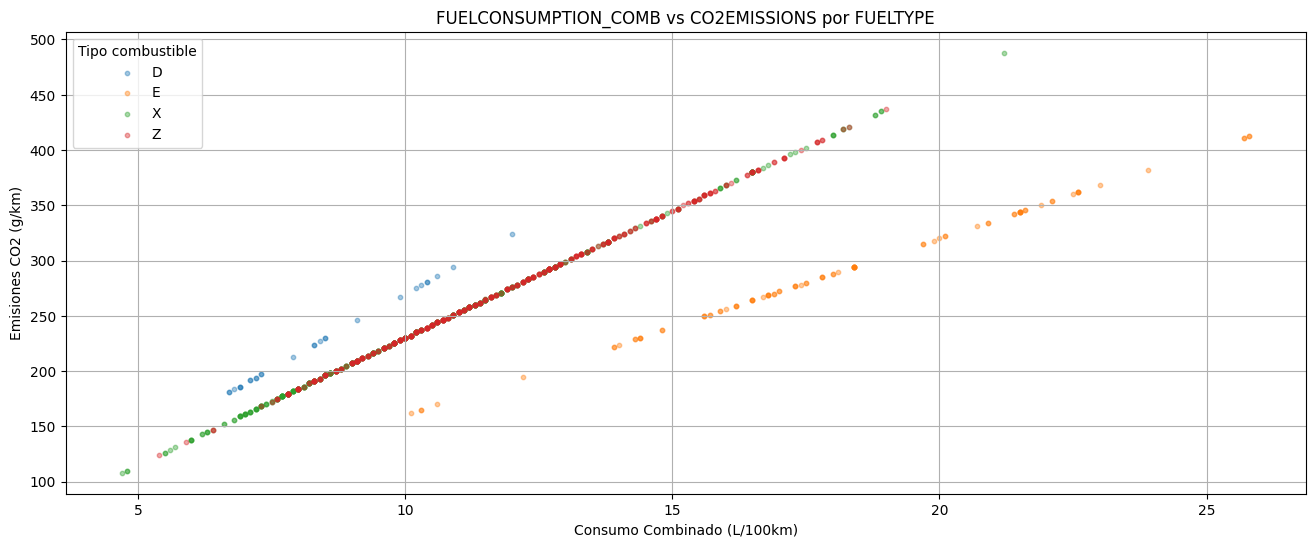

FUELTYPE
X    514
Z    434
E     92
D     27
Name: count, dtype: int64


In [12]:
# Viendo la regresión lineal simple de FUELCONSUMPTION_COMB se aprecian dos líneas de tendencia.
# La intuición me dice que probablemente sean dos relaciones lineales diferentes, función de una de las variables categóricas (probablemente el tipo de combustible)
# Esto es algo que se puede comprobar visualizando la relación entre FUELCONSUMPTION_COMB y CO2EMISSIONS segmentada por alguna de estas variables categóricas.
# Si se confirma esta hipótesis, podríamos considerar crear modelos de regresión lineal separados para cada segmento o incluir variables dummy para capturar estas diferencias en un modelo de regresión múltiple.

# Verificación de hipótesis: ¿hay dos tendencias lineales en FUELCONSUMPTION_COMB vs CO2EMISSIONS?                                                                            
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

# Por tipo de combustible (hipótesis principal)
for fueltype, group in df.groupby('FUELTYPE'):
    axes.scatter(group['FUELCONSUMPTION_COMB'], group['CO2EMISSIONS'],
                    alpha=0.4, label=fueltype, s=10)
axes.set_title('FUELCONSUMPTION_COMB vs CO2EMISSIONS por FUELTYPE')
axes.set_xlabel('Consumo Combinado (L/100km)')
axes.set_ylabel('Emisiones CO2 (g/km)')
axes.legend(title='Tipo combustible')
axes.grid(True)


plt.show()

# Cuántos registros hay por tipo de combustible
print(df['FUELTYPE'].value_counts())

# Aunque no es el objetivo de la práctica ya está clara cual es la relación:
# Sería una relación lineal entre FUELCONSUMPTION_COMB y CO2EMISSIONS, 
# pero con líneas de tendencia diferentes dependiendo del tipo de combustible (FUELTYPE).


In [13]:
# Tras este detour volvemos al modelo de regresión lineal múltiple, que es el que se va a usar en la app, 
# y que incluye las 3 variables numéricas (ENGINESIZE, CYLINDERS, FUELCONSUMPTION_COMB) como predictores de CO2EMISSIONS.
# 2. Entrenar el modelo múltiple
lin_reg_multi.fit(X_train_multi, y_train)

# 3. Coeficientes encontrados e interpretación
print("--- Coeficientes del Modelo Lineal Múltiple ---")

beta_0_multi = lin_reg_multi.intercept_
print(f"Intersección (β₀): {beta_0_multi:.2f}")
print(f"  Interpretación β₀: Valor predicho de CO2EMISSIONS si ENGINESIZE, CYLINDERS y FUELCONSUMPTION_COMB fueran todos cero (interpretación física limitada).")

print("\nCoeficientes (β₁, β₂, ...):")
coef_interpretations = []
feature_names = X_train_multi.columns # Asegúrate que X_train_multi tenga nombres de columnas
for feature, coef in zip(feature_names, lin_reg_multi.coef_):
    print(f"  Coeficiente para '{feature}' (βᵢ): {coef:.2f}")
    print(f"    Interpretación βᵢ: Por cada unidad de aumento en '{feature}', se espera que CO2EMISSIONS cambie en {coef:.2f} g/km, *manteniendo constantes las otras variables* ({', '.join(f for f in feature_names if f != feature)}).")
    coef_interpretations.append(f"({coef:.2f} * {feature})")

# Construir la ecuación del modelo
equation = f"CO2EMISSIONS ≈ {beta_0_multi:.2f} + {' + '.join(coef_interpretations)}"
print(f"\nEcuación del modelo:\n{equation}")





--- Coeficientes del Modelo Lineal Múltiple ---
Intersección (β₀): 67.35
  Interpretación β₀: Valor predicho de CO2EMISSIONS si ENGINESIZE, CYLINDERS y FUELCONSUMPTION_COMB fueran todos cero (interpretación física limitada).

Coeficientes (β₁, β₂, ...):
  Coeficiente para 'ENGINESIZE' (βᵢ): 11.21
    Interpretación βᵢ: Por cada unidad de aumento en 'ENGINESIZE', se espera que CO2EMISSIONS cambie en 11.21 g/km, *manteniendo constantes las otras variables* (CYLINDERS, FUELCONSUMPTION_COMB).
  Coeficiente para 'CYLINDERS' (βᵢ): 7.16
    Interpretación βᵢ: Por cada unidad de aumento en 'CYLINDERS', se espera que CO2EMISSIONS cambie en 7.16 g/km, *manteniendo constantes las otras variables* (ENGINESIZE, FUELCONSUMPTION_COMB).
  Coeficiente para 'FUELCONSUMPTION_COMB' (βᵢ): 9.52
    Interpretación βᵢ: Por cada unidad de aumento en 'FUELCONSUMPTION_COMB', se espera que CO2EMISSIONS cambie en 9.52 g/km, *manteniendo constantes las otras variables* (ENGINESIZE, CYLINDERS).

Ecuación del modelo:

### 4- Predecir con los datos de test
Realizamos el entrenamiento con una regresión lineal múltiple:

In [14]:
# 4. Predecir en el conjunto de prueba
y_pred_multi = lin_reg_multi.predict(X_test_multi)



### 5- Evaluar el modelo: Métricas
Evaluamos su rendimiento:


--- Evaluación del Modelo Múltiple (sobre datos de prueba) ---
R² (Coeficiente de Determinación): 0.8760
  Interpretación R²: Aproximadamente el 87.60% de la varianza en CO2EMISSIONS (test set) es explicada por el conjunto de variables ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB'] en este modelo lineal.

MSE (Mean Squared Error): 512.86
  Interpretación MSE: Promedio de los errores al cuadrado para el modelo múltiple. Unidades: (g/km)^2.

RMSE (Root Mean Squared Error): 22.65
  Interpretación RMSE: En promedio, las predicciones de este modelo múltiple se desvían unos 22.65 g/km de los valores reales de CO2EMISSIONS.

--- Comparación de Ajuste ---
R² (Simple con ENGINESIZE): 0.8071
R² (Múltiple con ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']): 0.8760
  Conclusión: Añadir las variables adicionales ha mejorado la capacidad explicativa del modelo lineal.

--- Visualización: Valores Reales vs. Predicciones ---
No podemos visualizar directamente la relación entre 3+ variables 

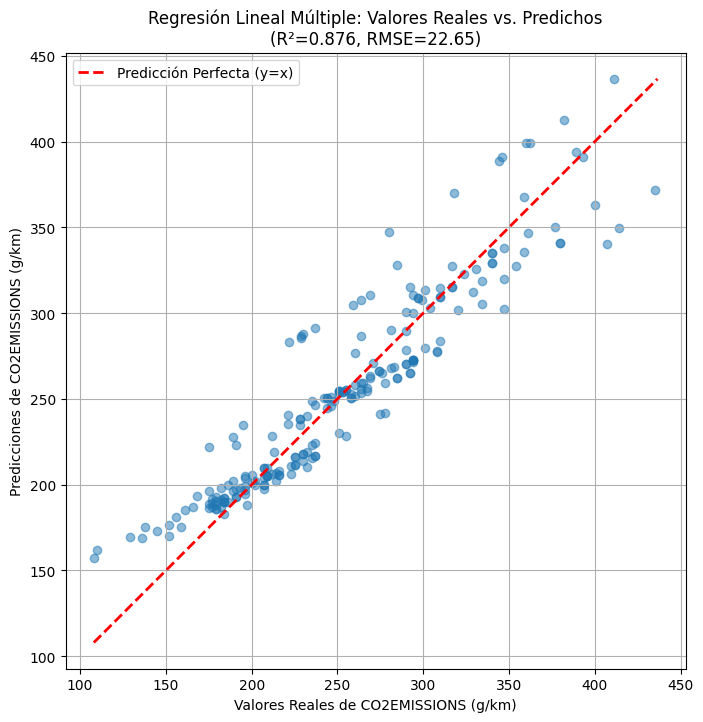

Interpretación del gráfico: Los puntos representan cada predicción de CO2.
Si la predicción hubiera sido perfecta el valor de CO2 predicho coincidiria con el real
y los puntos deberían haber caido sobre la línea roja discontinua (predicción perfecta).
La dispersión de los puntos alrededor de la línea indica el error del modelo.


In [15]:
from sklearn.metrics import mean_squared_error, r2_score

# 5. Evaluar e interpretar métricas
print(f"\n--- Evaluación del Modelo Múltiple (sobre datos de prueba) ---")

# R²
r2_multi = r2_score(y_test, y_pred_multi)
print(f"R² (Coeficiente de Determinación): {r2_multi:.4f}")
print(f"  Interpretación R²: Aproximadamente el {r2_multi*100:.2f}% de la varianza en CO2EMISSIONS (test set) es explicada por el conjunto de variables {list(feature_names)} en este modelo lineal.")

# MSE
mse_multi = mean_squared_error(y_test, y_pred_multi)
print(f"\nMSE (Mean Squared Error): {mse_multi:.2f}")
print(f"  Interpretación MSE: Promedio de los errores al cuadrado para el modelo múltiple. Unidades: (g/km)^2.")

# RMSE
rmse_multi = np.sqrt(mse_multi)
print(f"\nRMSE (Root Mean Squared Error): {rmse_multi:.2f}")
print(f"  Interpretación RMSE: En promedio, las predicciones de este modelo múltiple se desvían unos {rmse_multi:.2f} g/km de los valores reales de CO2EMISSIONS.")

# 6. Comparación con Regresión Simple (Asumiendo r2_simple calculado previamente)
# Definir r2_simple si no viene de antes (solo para ejemplo)
# r2_simple = 0.7616 # Valor obtenido antes
try:
    print(f"\n--- Comparación de Ajuste ---")
    print(f"R² (Simple con ENGINESIZE): {r2_simple:.4f}")
    print(f"R² (Múltiple con {list(feature_names)}): {r2_multi:.4f}")
    if r2_multi > r2_simple:
        print("  Conclusión: Añadir las variables adicionales ha mejorado la capacidad explicativa del modelo lineal.")
    else:
        print("  Conclusión: Añadir las variables adicionales NO ha mejorado (o ha empeorado ligeramente) la capacidad explicativa del modelo lineal en el test set.")
except NameError:
    print("\nVariable 'r2_simple' no encontrada para comparación.")

# 7. Visualización (Actual vs. Predicho)
print("\n--- Visualización: Valores Reales vs. Predicciones ---")
print("""No podemos visualizar directamente la relación entre 3+ variables predictoras y la variable
  objetivo en un gráfico 2D simple como hacíamos con la regresión lineal simple (que era una línea),
  una visualización muy útil y estándar para cualquier modelo de regresión (incluido el múltiple) es
  graficar los valores reales contra los valores predichos.
->Idea de la Visualización:
Eje X: Valores reales de CO2EMISSIONS del conjunto de prueba (y_test).
Eje Y: Valores predichos por el modelo múltiple para esas mismas muestras (y_pred_multi).
Línea de Referencia: Una línea diagonal (y=x) que representa la predicción perfecta (donde predicho == real).
Si el modelo es bueno, los puntos (real, predicho) deberían agruparse cerca de esta línea diagonal.
La dispersión alrededor de la línea da una idea visual del error del modelo (relacionado con el RMSE y R²).\n
""");

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_multi, alpha=0.5)

# Añadir la línea de referencia y=x (predicción perfecta)
min_val = min(y_test.min(), y_pred_multi.min())
max_val = max(y_test.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Regresión Lineal Múltiple: Valores Reales vs. Predichos\n(R²={r2_multi:.3f}, RMSE={rmse_multi:.2f})')
plt.xlabel('Valores Reales de CO2EMISSIONS (g/km)')
plt.ylabel('Predicciones de CO2EMISSIONS (g/km)')
plt.legend()
plt.grid(True)
# Asegurar que los ejes tengan escalas comparables si es posible
plt.axis('equal') # Forza a que la escala en X e Y sea la misma
plt.show()

print("Interpretación del gráfico: Los puntos representan cada predicción de CO2.")
print("Si la predicción hubiera sido perfecta el valor de CO2 predicho coincidiria con el real")
print("y los puntos deberían haber caido sobre la línea roja discontinua (predicción perfecta).")
print("La dispersión de los puntos alrededor de la línea indica el error del modelo.")

### 6- Predecir simulando una entrada vía web  <-- Guiado

Creamos una entrada nueva y se la pasamos al predictor. Esto será lo que tendremos que hacer con el modelo cuando interactuemos via web realizandole consultas:

In [16]:
X_web = pd.DataFrame([[1.4, 4.0, 7.8]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB'])
p_pred_web = lin_reg_multi.predict(X_web)
p_pred_web[0]# quitamos corchetes de p_pred=[185.92...]

np.float64(185.92638775794967)

### 7.- Pipelines: Procesar datos de entrada  <-- NOVEDAD

En algunos casos es conveniente preprocesar los datos de entrada y esto nos obliga a crear un pipeline que irá aplicando cada uno de los preprocesos. En este caso tan simplificado solo se preprocesa pasando los datos de entrada por el modelo, pero podríamos crear un pipepile con tantas lineas de preprocesamiento como preprocesos tenga (por ejemplo para normalizar):

In [17]:
from sklearn.pipeline import Pipeline
# Construimos un pipeline con los pasos a realizar sobre los datos:
pipeline = Pipeline([
    ('regressor', lin_reg_multi)
])

El pipeline se utiliza para realizar predicciones en nuevos datos, asegurándose de aplicar la misma transformación a las características que se utilizó durante el entrenamiento del modelo.

In [18]:
X_train_multi.iloc[0]

ENGINESIZE              1.4
CYLINDERS               4.0
FUELCONSUMPTION_COMB    7.8
Name: 333, dtype: float64

Comprobemos que devuelve algo adecuado:

In [19]:
print(X_train_multi.iloc[0])
prediction = pipeline.predict(pd.DataFrame([X_train_multi.iloc[0]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']))
print(prediction[0])

ENGINESIZE              1.4
CYLINDERS               4.0
FUELCONSUMPTION_COMB    7.8
Name: 333, dtype: float64
185.92638775794967


In [20]:
prediction

array([185.92638776])

Simulando que introducimos manualmente los valores de las columnas para ser procesadas por el pipeline vemos que obtenemos el mismo resultado:

In [21]:
prediction = pipeline.predict(pd.DataFrame([[1.4, 4.0, 7.8]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']))
prediction[0]

np.float64(185.92638775794967)

### 8.- Pickle: Persistir modelo  <-- NOVEDAD

Necesitamos un archivo que pueda ser utilizado para cargar el modelo y realizar predicciones sin tener que volver a entrenar el modelo desde cero en nuestra web:

In [22]:
import pickle
with open('pipeline.pickle','wb') as f: #Abrimos archivo en modo escritura binaria
    pickle.dump(pipeline, f) #Guardamos objeto pipeline a un archivo binario

En el backend de nuestra webapp en Flask necesitaremos poder recuperar el modelo que hemos guardado en un archivo binario de manera similar a como se muestra a continuación:

In [23]:
#Cargamos el pipeline desde el archivo pickle con el nombre "loaded_pipe"
with open('pipeline.pickle','rb') as f:
    loaded_pipe = pickle.load(f)
#comprobamos realizando una nueva predicción con el pipeline
prediction = loaded_pipe.predict(pd.DataFrame([[1.4, 4.0, 7.8]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']))
prediction[0]


np.float64(185.92638775794967)

**Desde el notebook ya tenemos todo lo necesario para realizar nuestra 1º webapp que utiliza un modelo de Machine Learning**